<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/MLP_datos_sinteticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Taller en clase: 14/10/2025**

#**Base de datos: wheather_feature - variable de interes: wind_speed**
#Julian David Morales Pineda

#**Notebook completo — MLP con datos sintéticos**

#Celda 1 — Parámetros y configuración base

In [ ]:
# ===== Celda 1: Parámetros globales =====
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
from scipy.signal import periodogram
import pandas as pd
import random
import os

# -------- Parámetros controlables --------
BATCH_SIZE = 64         # tamaño de batch
EPOCHS = 120            # número de épocas
N_SAMPLES_SYN = 5000    # muestras sintéticas
LEARNING_RATE = 1e-3    # tasa de aprendizaje
SEQ_LEN = 1024          # longitud de señal (puntos)
FS = 200.0              # frecuencia de muestreo (Hz)

# reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f"Configuración:\n  N_SAMPLES_SYN={N_SAMPLES_SYN}\n  EPOCHS={EPOCHS}\n  BATCH_SIZE={BATCH_SIZE}\n  LEARNING_RATE={LEARNING_RATE}\n  SEQ_LEN={SEQ_LEN}")


Configuración:
  N_SAMPLES_SYN=5000
  EPOCHS=120
  BATCH_SIZE=64
  LEARNING_RATE=0.001
  SEQ_LEN=1024


#Celda 2 — Generación y procesamiento de datos sintéticos (Harmonics + Noise + PSD)

✅ Generadas 5000 señales sintéticas de 1024 puntos con sus PSDs (Welch).


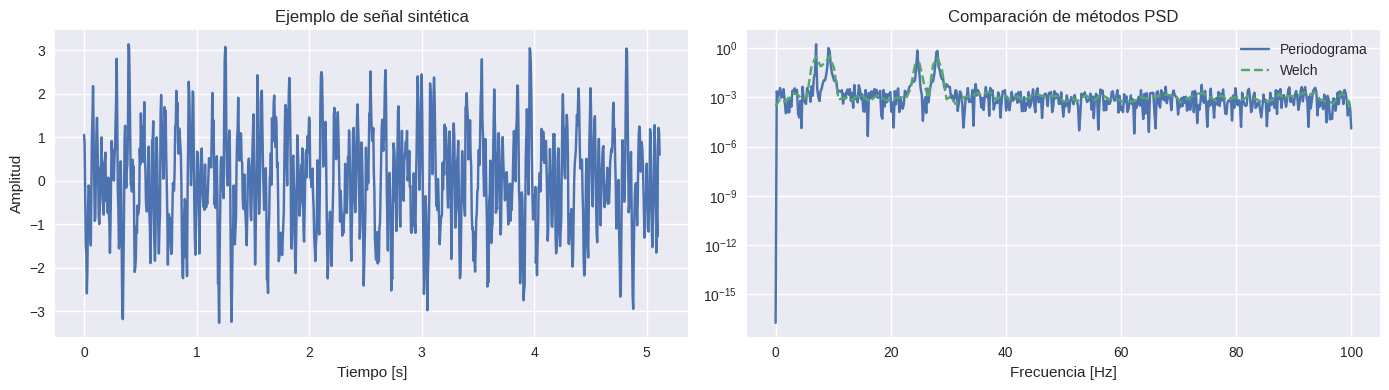

In [ ]:
# ===== Celda 2: Generación y procesamiento de datos sintéticos =====

from scipy.signal import welch

def generate_signal(t, freqs, amps, phases):
    """Genera una señal senoidal con armónicos."""
    s = np.zeros_like(t)
    for f, a, p in zip(freqs, amps, phases):
        s += a * np.sin(2 * np.pi * f * t + p)
    return s

def add_noise(signal, noise_std=0.3):
    """Agrega ruido gaussiano."""
    return signal + noise_std * np.random.randn(*signal.shape)

# Tiempo de muestreo
t = np.arange(SEQ_LEN) / FS

# Arreglos para señales y PSDs
X = np.zeros((N_SAMPLES_SYN, SEQ_LEN), dtype=np.float32)
Y = np.zeros((N_SAMPLES_SYN, SEQ_LEN//2 + 1), dtype=np.float32)  # PSD con rfft

for i in range(N_SAMPLES_SYN):
    # Frecuencias y amplitudes aleatorias
    num_harmonics = np.random.randint(2, 5)
    freqs = np.random.uniform(1, 30, num_harmonics)
    amps = np.random.uniform(0.3, 1.0, num_harmonics)
    phases = np.random.uniform(0, 2*np.pi, num_harmonics)
    signal_clean = generate_signal(t, freqs, amps, phases)
    signal_noisy = add_noise(signal_clean, noise_std=np.random.uniform(0.05, 0.4))

    # Calcular PSD usando Welch (mejor estabilidad)
    f, Pxx = welch(signal_noisy, fs=FS, nperseg=256)
    Pxx = Pxx / np.max(Pxx + 1e-8)  # Normalizar PSD

    # Redimensionar o interpolar a 513 puntos
    if len(Pxx) != SEQ_LEN//2 + 1:
        Pxx = np.interp(np.linspace(0, len(Pxx)-1, SEQ_LEN//2 + 1), np.arange(len(Pxx)), Pxx)

    X[i] = signal_noisy
    Y[i] = Pxx

print(f"✅ Generadas {N_SAMPLES_SYN} señales sintéticas de {SEQ_LEN} puntos con sus PSDs (Welch).")

# Ejemplo de señal y sus PSDs (Periodograma y Welch)
idx = np.random.randint(0, N_SAMPLES_SYN)
sig = X[idx]
f_p, Pxx_p = periodogram(sig, fs=FS)
f_w, Pxx_w = welch(sig, fs=FS, nperseg=256)

plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
plt.plot(t, sig)
plt.title('Ejemplo de señal sintética')
plt.xlabel('Tiempo [s]'); plt.ylabel('Amplitud')

plt.subplot(1,2,2)
plt.semilogy(f_p, Pxx_p, label='Periodograma')
plt.semilogy(f_w, Pxx_w, label='Welch', linestyle='--')
plt.title('Comparación de métodos PSD')
plt.xlabel('Frecuencia [Hz]')
plt.legend()
plt.tight_layout()
plt.show()


**Celda 1 — Import y generación de datos sintéticos (entrada 1024, salida 1024). Mostrar periodograma**

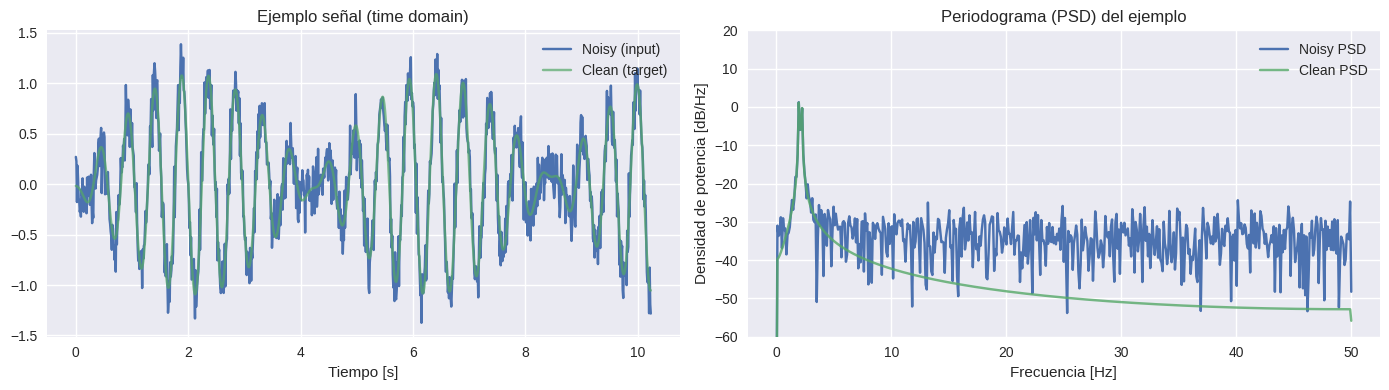

Ejemplo índice: 1859. Tamaño dataset: 5000 muestras, secuencia: 1024


In [ ]:
# ===== Celda 1: Imports y generación de datos sintéticos (input=1024, target=1024) =====
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
from scipy.signal import periodogram
import random
import os

# reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

# parámetros de las señales
fs = 100.0             # frecuencia de muestreo (Hz) - sólo informativa para el PSD
seq_len = 1024         # longitud de entrada/salida pedida
N_samples = 5000       # número de ejemplos sintéticos (ajusta según RAM)
t = np.arange(seq_len) / fs

# función para crear una señal limpia con armónicos y luego ruido
def make_clean_signal(t, freqs=[0.5, 1.2, 2.5], amps=[1.0, 0.6, 0.3], phases=None):
    if phases is None:
        phases = [np.random.uniform(0, 2*np.pi) for _ in freqs]
    s = np.zeros_like(t, dtype=float)
    for f, a, p in zip(freqs, amps, phases):
        s += a * np.sin(2*np.pi*f*t + p)
    return s

def make_noisy_signal(clean, snr_db=None, noise_std=None):
    # permite definir SNR o std de ruido
    if snr_db is not None:
        power_signal = np.mean(clean**2)
        power_noise = power_signal / (10**(snr_db/10))
        noise_std = np.sqrt(power_noise)
    if noise_std is None:
        noise_std = 0.3 * np.std(clean)
    noise = noise_std * np.random.randn(*clean.shape)
    return clean + noise

# construir dataset sintético: input = señal ruidosa, target = señal limpia (denoising)
X = np.zeros((N_samples, seq_len), dtype=np.float32)
Y = np.zeros((N_samples, seq_len), dtype=np.float32)

for i in range(N_samples):
    # variabilidad aleatoria en frecuencias, amplitudes y fases
    base_freqs = [np.random.uniform(0.3, 2.0), np.random.uniform(2.0, 6.0)]
    # agregar uno o dos armónicos extra aleatorios
    # Fix: Sample directly from a list of possible frequencies instead of creating an intermediate list of lists
    extra_freqs = np.random.choice([6, 8, 10, 12], size=np.random.choice([0, 1, 2], p=[0.7, 0.2, 0.1]), replace=False)
    freqs = base_freqs + list(extra_freqs)
    amps = [np.random.uniform(0.3, 1.2) for _ in freqs]
    phases = [np.random.uniform(0, 2*np.pi) for _ in freqs]
    clean = make_clean_signal(t, freqs, amps, phases)
    noisy = make_noisy_signal(clean, noise_std=np.random.uniform(0.05, 0.6))
    X[i] = noisy.astype(np.float32)
    Y[i] = clean.astype(np.float32)

# Opcional: si quieres mezclar con datos reales de wind_speed, carga tu archivo y concatena (descomenta)
# import pandas as pd
# if os.path.exists('wheather_feature.txt'):
#     df = pd.read_csv('wheather_feature.txt')
#     wind = df['wind_speed'].values
#     # Normalizar y extraer ventanas de longitud seq_len
#     wind = (wind - np.mean(wind)) / (np.std(wind) + 1e-9)
#     # crear ventanas sin superponer
#     n_windows = min(200, len(wind)//seq_len)
#     for i in range(n_windows):
#         seg = wind[i*seq_len:(i+1)*seq_len]
#         if len(seg)==seq_len:
#             X[i % N_samples] = (seg + 0.1*np.random.randn(seq_len)).astype(np.float32)
#             Y[i % N_samples] = seg.astype(np.float32)

# Mostrar un ejemplo y su periodograma (señal ruidosa)
idx = np.random.randint(0, N_samples)
example_noisy = X[idx]
example_clean = Y[idx]

f, Pxx_noisy = periodogram(example_noisy, fs=fs)
f_c, Pxx_clean = periodogram(example_clean, fs=fs)

plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
plt.plot(t, example_noisy, label='Noisy (input)')
plt.plot(t, example_clean, label='Clean (target)', alpha=0.7)
plt.title('Ejemplo señal (time domain)')
plt.xlabel('Tiempo [s]')
plt.legend()

plt.subplot(1,2,2)
# Convert PSD to dB scale
Pxx_noisy_db = 10 * np.log10(Pxx_noisy + 1e-9) # Add a small epsilon to avoid log(0)
Pxx_clean_db = 10 * np.log10(Pxx_clean + 1e-9)

plt.plot(f, Pxx_noisy_db, label='Noisy PSD')
plt.plot(f_c, Pxx_clean_db, label='Clean PSD', alpha=0.8)
plt.title('Periodograma (PSD) del ejemplo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB/Hz]') # Update y-axis label for dB scale
plt.legend()
plt.ylim([-60, 20]) # Set y-axis limits in dB
plt.tight_layout()
plt.show()

print(f"Ejemplo índice: {idx}. Tamaño dataset: {N_samples} muestras, secuencia: {seq_len}")

**Celda 2 — Parámetros de entrenamiento y configuración base**

In [ ]:
# ===== Celda 2: Parámetros globales =====

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
from scipy.signal import periodogram
import random
import os

# -------- Parámetros controlables --------
BATCH_SIZE = 16         # tamaño del batch
EPOCHS = 100            # número de iteraciones de entrenamiento
N_SAMPLES = 2000        # número de señales sintéticas
LEARNING_RATE = 1e-3    # tasa de aprendizaje

SEQ_LEN = 1024          # puntos de entrada/salida
FS = 100.0              # frecuencia de muestreo (Hz)

# reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f"Configuración:\n  N_SAMPLES={N_SAMPLES}\n  EPOCHS={EPOCHS}\n  BATCH_SIZE={BATCH_SIZE}\n  LEARNING_RATE={LEARNING_RATE}\n  SEQ_LEN={SEQ_LEN}")


Configuración:
  N_SAMPLES=2000
  EPOCHS=100
  BATCH_SIZE=16
  LEARNING_RATE=0.001
  SEQ_LEN=1024


**Generación de datos sintéticos con armónicos y ruido (y periodograma)**

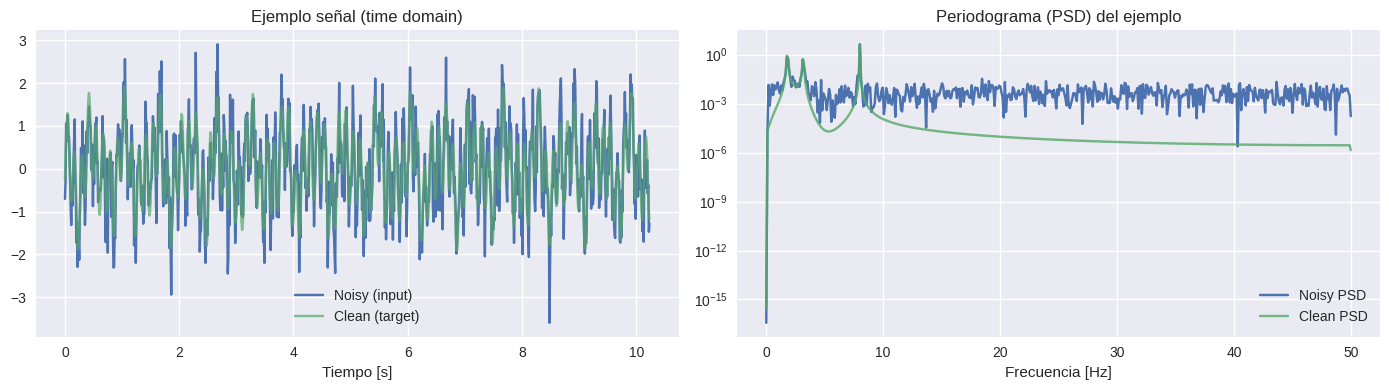

Dataset generado: 2000 muestras de longitud 1024


In [ ]:
# ===== Generación de señales sintéticas =====

t = np.arange(SEQ_LEN) / FS

def make_clean_signal(t, freqs=[0.5, 1.2, 2.5], amps=[1.0, 0.6, 0.3], phases=None):
    if phases is None:
        phases = [np.random.uniform(0, 2*np.pi) for _ in freqs]
    s = np.zeros_like(t, dtype=float)
    for f, a, p in zip(freqs, amps, phases):
        s += a * np.sin(2*np.pi*f*t + p)
    return s

def make_noisy_signal(clean, snr_db=None, noise_std=None):
    if snr_db is not None:
        power_signal = np.mean(clean**2)
        power_noise = power_signal / (10**(snr_db/10))
        noise_std = np.sqrt(power_noise)
    if noise_std is None:
        noise_std = 0.3 * np.std(clean)
    noise = noise_std * np.random.randn(*clean.shape)
    return clean + noise

# generar dataset
X = np.zeros((N_SAMPLES, SEQ_LEN), dtype=np.float32)
Y = np.zeros((N_SAMPLES, SEQ_LEN), dtype=np.float32)

for i in range(N_SAMPLES):
    base_freqs = [np.random.uniform(0.3, 2.0), np.random.uniform(2.0, 6.0)]
    # Fix: Sample directly from a list of possible frequencies instead of creating an intermediate list of lists
    extra_freqs = np.random.choice([6, 8, 10, 12], size=np.random.choice([0, 1, 2], p=[0.7, 0.2, 0.1]), replace=False)
    freqs = base_freqs + list(extra_freqs)
    amps = [np.random.uniform(0.3, 1.2) for _ in freqs]
    phases = [np.random.uniform(0, 2*np.pi) for _ in freqs]
    clean = make_clean_signal(t, freqs, amps, phases)
    noisy = make_noisy_signal(clean, noise_std=np.random.uniform(0.05, 0.6))
    X[i] = noisy.astype(np.float32)
    Y[i] = clean.astype(np.float32)


# Ejemplo de periodograma
idx = np.random.randint(0, N_SAMPLES)
example_noisy = X[idx]
example_clean = Y[idx]

f, Pxx_noisy = periodogram(example_noisy, fs=FS)
f_c, Pxx_clean = periodogram(example_clean, fs=FS)

plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
plt.plot(t, example_noisy, label='Noisy (input)')
plt.plot(t, example_clean, label='Clean (target)', alpha=0.7)
plt.title('Ejemplo señal (time domain)')
plt.xlabel('Tiempo [s]')
plt.legend()

plt.subplot(1,2,2)
plt.semilogy(f, Pxx_noisy, label='Noisy PSD')
plt.semilogy(f_c, Pxx_clean, label='Clean PSD', alpha=0.8)
plt.title('Periodograma (PSD) del ejemplo')
plt.xlabel('Frecuencia [Hz]')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Dataset generado: {N_SAMPLES} muestras de longitud {SEQ_LEN}")

**Celda 3 — Preparar datos, división 70/15/15 y DataLoaders**

1.   train = 70%
2.   test = 15 %
3.   validation = 15%



In [ ]:
# ===== Celda 3: Dataset, split y DataLoaders =====
X_tensor = torch.from_numpy(X)
Y_tensor = torch.from_numpy(Y)

dataset = TensorDataset(X_tensor, Y_tensor)
N = len(dataset)

train_n = int(0.70 * N)
val_n = int(0.15 * N)
test_n = N - train_n - val_n

train_ds, val_ds, test_ds = random_split(dataset, [train_n, val_n, test_n])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Split -> Train: {train_n}, Val: {val_n}, Test: {test_n}")


Split -> Train: 1400, Val: 300, Test: 300


**Celda 4 — Definición de la arquitectura MLP**

In [ ]:
# ===== Celda 4: Modelo MLP =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class MLP_Denoiser(nn.Module):
    def __init__(self, seq_len=1024, hidden_dims=[1024, 512, 256]):
        super().__init__()
        layers = []
        in_dim = seq_len
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        for h in reversed(hidden_dims[:-1]):
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, seq_len))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP_Denoiser(seq_len=SEQ_LEN).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)


Device: cuda
MLP_Denoiser(
  (net): Sequential(
    (0): Linear(in_features=1024, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=1024, bias=True)
    (9): ReLU()
    (10): Linear(in_features=1024, out_features=1024, bias=True)
  )
)


**Celda 5 — Entrenamiento (con control de loss y accuracy R²)**

Época 1/100 - Train Loss: 0.723593 | Val Loss: 0.697326 | Val R²: 0.0560
Época 10/100 - Train Loss: 0.502848 | Val Loss: 0.570974 | Val R²: 0.2258
Época 20/100 - Train Loss: 0.345260 | Val Loss: 0.504863 | Val R²: 0.3242
Época 30/100 - Train Loss: 0.257790 | Val Loss: 0.505478 | Val R²: 0.3284
Época 40/100 - Train Loss: 0.194623 | Val Loss: 0.516312 | Val R²: 0.3135
Época 50/100 - Train Loss: 0.145882 | Val Loss: 0.513446 | Val R²: 0.3157
Época 60/100 - Train Loss: 0.120979 | Val Loss: 0.524152 | Val R²: 0.3039
Época 70/100 - Train Loss: 0.097289 | Val Loss: 0.525286 | Val R²: 0.3029
Época 80/100 - Train Loss: 0.098721 | Val Loss: 0.531015 | Val R²: 0.2944
Época 90/100 - Train Loss: 0.076112 | Val Loss: 0.529234 | Val R²: 0.2970
Época 100/100 - Train Loss: 0.078395 | Val Loss: 0.531496 | Val R²: 0.2927


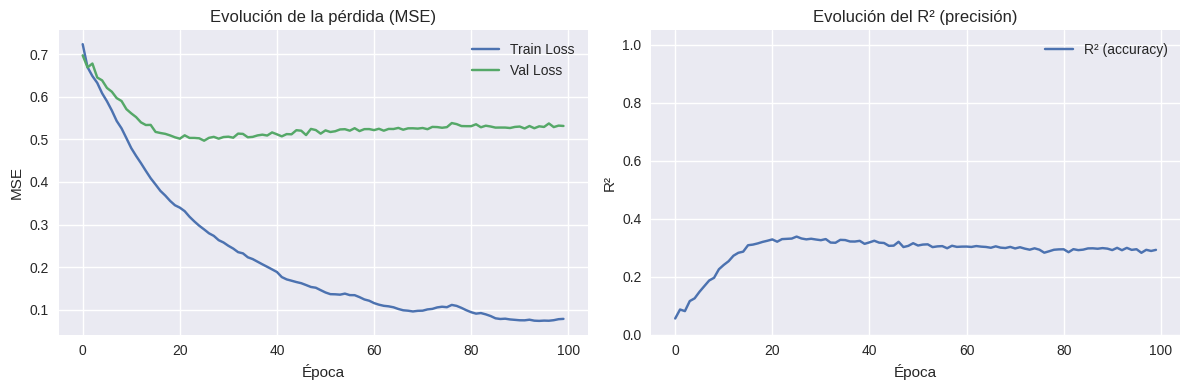

In [ ]:
# ===== Celda 5: Entrenamiento =====
def r2_score_torch(y_true, y_pred):
    y_true_mean = torch.mean(y_true, dim=1, keepdim=True)
    ss_res = torch.sum((y_true - y_pred)**2, dim=1)
    ss_tot = torch.sum((y_true - y_true_mean)**2, dim=1) + 1e-9
    r2 = 1.0 - ss_res / ss_tot
    return torch.mean(r2).item()

train_losses, val_losses, val_r2s = [], [], []
best_val_loss = float('inf')
best_state = None

for epoch in range(1, EPOCHS+1):
    # --- Entrenamiento ---
    model.train()
    total_train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * xb.size(0)
    train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # --- Validación ---
    model.eval()
    total_val_loss, total_r2 = 0.0, 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            total_val_loss += loss.item() * xb.size(0)
            total_r2 += r2_score_torch(yb, y_pred) * xb.size(0)
    val_loss = total_val_loss / len(val_loader.dataset)
    val_r2 = total_r2 / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_r2s.append(val_r2)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()

    if epoch % 10 == 0 or epoch == 1:
        print(f"Época {epoch}/{EPOCHS} - Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Val R²: {val_r2:.4f}")

# restaurar mejor modelo
if best_state is not None:
    model.load_state_dict(best_state)

# --- Graficar curvas ---
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Evolución de la pérdida (MSE)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_r2s, label='R² (accuracy)')
plt.title('Evolución del R² (precisión)')
plt.xlabel('Época')
plt.ylabel('R²')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


**Celda 6 — Evaluación y visualización final**


🔹 MSE (Test): 0.550286
🔹 R² (Test): 0.2772


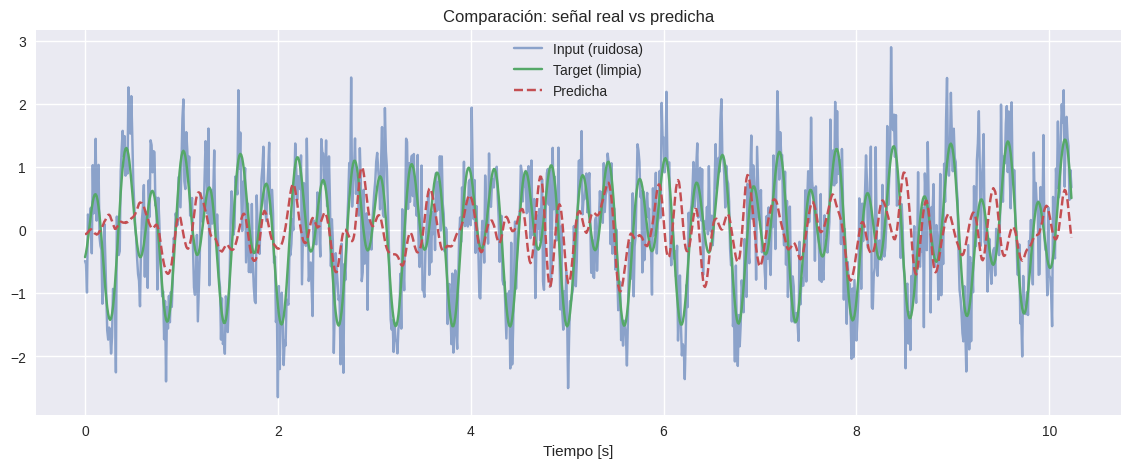

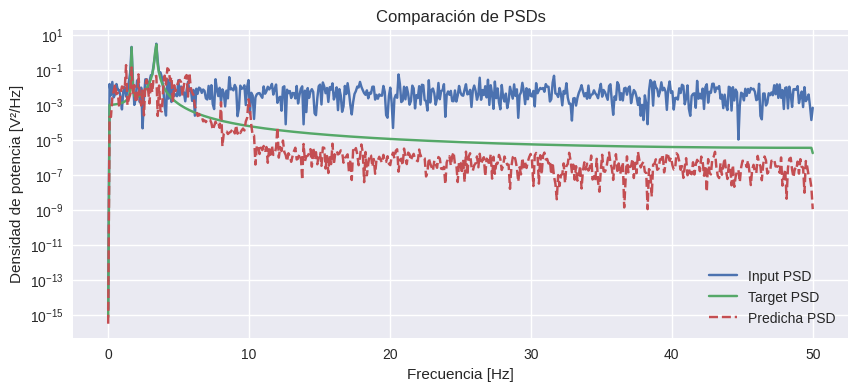

In [ ]:
# ===== Celda 6: Evaluación final =====
model.eval()
mse_test, r2_test = 0.0, 0.0
preds, trues = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        y_pred = model(xb)
        mse_test += criterion(y_pred, yb).item() * xb.size(0)
        r2_test += r2_score_torch(yb, y_pred) * xb.size(0)
        preds.append(y_pred.cpu().numpy())
        trues.append(yb.cpu().numpy())

mse_test /= len(test_loader.dataset)
r2_test /= len(test_loader.dataset)

print(f"\n🔹 MSE (Test): {mse_test:.6f}")
print(f"🔹 R² (Test): {r2_test:.4f}")

preds = np.vstack(preds)
trues = np.vstack(trues)

# ejemplo visual
idx = np.random.randint(0, len(test_ds))
x_input = test_ds[idx][0].numpy()
y_true = test_ds[idx][1].numpy()
y_pred = model(torch.from_numpy(x_input).unsqueeze(0).to(device)).cpu().detach().numpy().squeeze()

plt.figure(figsize=(14,5))
plt.plot(np.arange(SEQ_LEN)/FS, x_input, label='Input (ruidosa)', alpha=0.6)
plt.plot(np.arange(SEQ_LEN)/FS, y_true, label='Target (limpia)')
plt.plot(np.arange(SEQ_LEN)/FS, y_pred, label='Predicha', linestyle='--')
plt.xlabel('Tiempo [s]')
plt.legend()
plt.title('Comparación: señal real vs predicha')
plt.show()

# periodogramas comparativos
f_in, Pxx_in = periodogram(x_input, fs=FS)
f_true, Pxx_true = periodogram(y_true, fs=FS)
f_pred, Pxx_pred = periodogram(y_pred, fs=FS)

plt.figure(figsize=(10,4))
plt.semilogy(f_in, Pxx_in, label='Input PSD')
plt.semilogy(f_true, Pxx_true, label='Target PSD')
plt.semilogy(f_pred, Pxx_pred, label='Predicha PSD', linestyle='--')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [V²/Hz]')
plt.legend()
plt.title('Comparación de PSDs')
plt.show()

#Celda 3 — División del dataset (60% Train / 20% Valid / 20% Test)

In [ ]:
# ===== Celda 3: División de dataset =====

X_tensor = torch.from_numpy(X)
Y_tensor = torch.from_numpy(Y)

dataset = TensorDataset(X_tensor, Y_tensor)

# División
train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Split -> Train: {train_size}, Val: {val_size}, Test: {test_size}")


Split -> Train: 3000, Val: 1000, Test: 1000


#Celda 4 — Definición del modelo MLP

In [ ]:
# ===== Celda 4: Definición de la arquitectura MLP =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class MLP_PSD(nn.Module):
    def __init__(self, input_size=1024, output_size=513):
        super(MLP_PSD, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, output_size),
            nn.Softplus()  # garantiza PSD positiva
        )

    def forward(self, x):
        return self.net(x)

model = MLP_PSD(input_size=SEQ_LEN, output_size=SEQ_LEN//2 + 1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)


Device: cuda
MLP_PSD(
  (net): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=513, bias=True)
    (5): Softplus(beta=1.0, threshold=20.0)
  )
)


#Celda 5 — Entrenamiento del modelo usando solo LOSS

Época 1/120 | Train Loss: 0.000106 | Val Loss: 0.002032
Época 10/120 | Train Loss: 0.000099 | Val Loss: 0.002060
Época 20/120 | Train Loss: 0.000113 | Val Loss: 0.002059
Época 30/120 | Train Loss: 0.000087 | Val Loss: 0.001992
Época 40/120 | Train Loss: 0.000106 | Val Loss: 0.002033
Época 50/120 | Train Loss: 0.000126 | Val Loss: 0.002020
Época 60/120 | Train Loss: 0.000077 | Val Loss: 0.002001
Época 70/120 | Train Loss: 0.000090 | Val Loss: 0.002006
Época 80/120 | Train Loss: 0.000107 | Val Loss: 0.002042
Época 90/120 | Train Loss: 0.000088 | Val Loss: 0.001975
Época 100/120 | Train Loss: 0.000092 | Val Loss: 0.001984
Época 110/120 | Train Loss: 0.000090 | Val Loss: 0.001964
Época 120/120 | Train Loss: 0.000089 | Val Loss: 0.002000


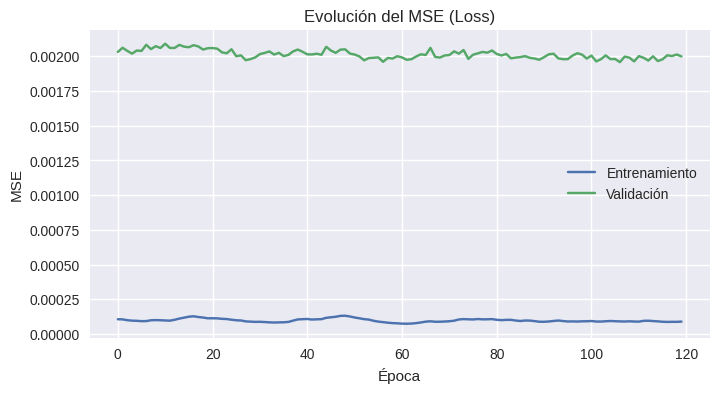

In [ ]:
# ===== Celda 5: Entrenamiento =====

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validación
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Época {epoch}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

# Graficar pérdidas
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Entrenamiento')
plt.plot(val_losses, label='Validación')
plt.title('Evolución del MSE (Loss)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()


#Add Patience (con Early Stopping)

Época 001/120 | Train Loss: 8.957830e-05 | Val Loss: 1.973499e-03
Época 002/120 | Train Loss: 9.524092e-05 | Val Loss: 2.001943e-03
   ↳ Sin mejora (1/15)
Época 003/120 | Train Loss: 1.001667e-04 | Val Loss: 1.999870e-03
   ↳ Sin mejora (2/15)
Época 004/120 | Train Loss: 1.040208e-04 | Val Loss: 1.990252e-03
   ↳ Sin mejora (3/15)
Época 005/120 | Train Loss: 1.032816e-04 | Val Loss: 1.998319e-03
   ↳ Sin mejora (4/15)
Época 006/120 | Train Loss: 1.014184e-04 | Val Loss: 2.039010e-03
   ↳ Sin mejora (5/15)
Época 007/120 | Train Loss: 1.036962e-04 | Val Loss: 2.043444e-03
   ↳ Sin mejora (6/15)
Época 008/120 | Train Loss: 1.025063e-04 | Val Loss: 1.996520e-03
   ↳ Sin mejora (7/15)
Época 009/120 | Train Loss: 1.020106e-04 | Val Loss: 1.993259e-03
   ↳ Sin mejora (8/15)
Época 010/120 | Train Loss: 9.638115e-05 | Val Loss: 1.969185e-03
Época 011/120 | Train Loss: 9.170173e-05 | Val Loss: 2.016352e-03
   ↳ Sin mejora (1/15)
Época 012/120 | Train Loss: 8.869968e-05 | Val Loss: 1.983664e-03
 

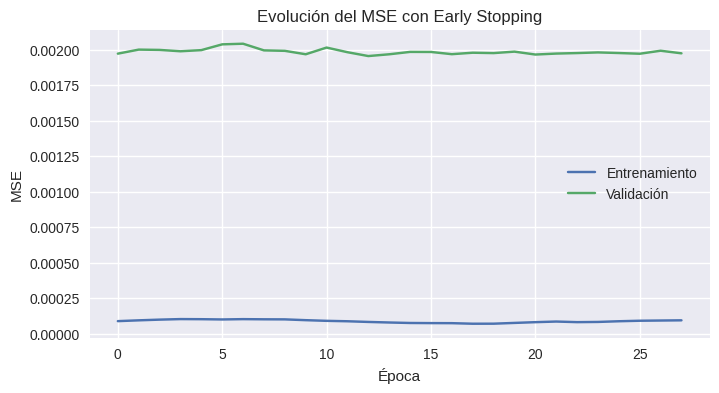

In [ ]:
# ===== Celda 5: Entrenamiento con Early Stopping (paciencia) =====

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience = 15      # número de épocas de paciencia
counter = 0        # contador de épocas sin mejora
best_model_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # --- Validación ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Época {epoch:03d}/{EPOCHS} | Train Loss: {train_loss:.6e} | Val Loss: {val_loss:.6e}")

    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        counter = 0  # reset patience counter
    else:
        counter += 1
        print(f"   ↳ Sin mejora ({counter}/{patience})")

    if counter >= patience:
        print(f"\n⏹️ Early Stopping activado: no hay mejora en {patience} épocas consecutivas.")
        break

# Restaurar mejor modelo
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("\n✅ Modelo restaurado al mejor estado de validación.")

# Graficar pérdidas
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Entrenamiento')
plt.plot(val_losses, label='Validación')
plt.title('Evolución del MSE con Early Stopping')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()


#Celda 6 — Evaluación y prueba del modelo


📊 Pérdida (MSE) en test: 2.066437e-03


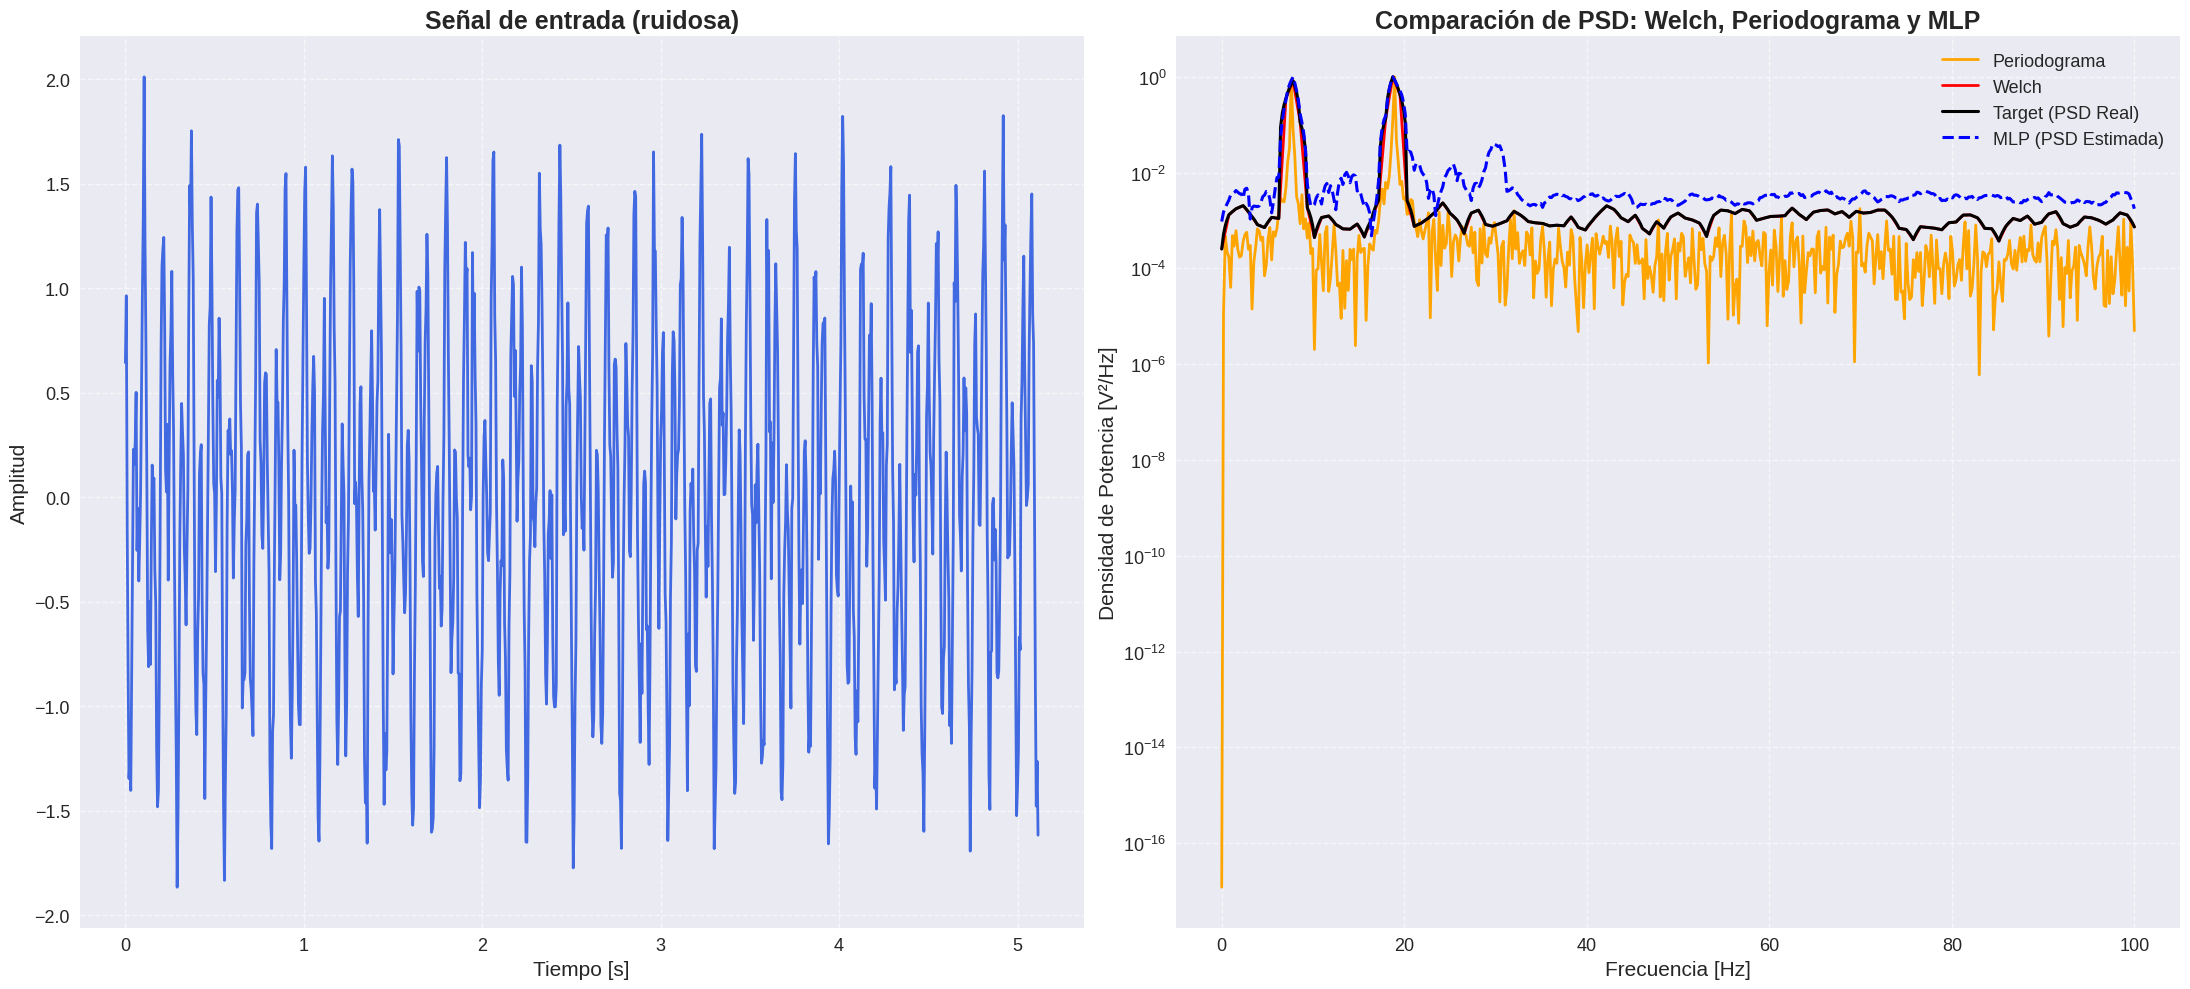

In [ ]:
# ===== Celda 6: Evaluación y prueba (con Welch y Periodograma, versión extra grande) =====
from scipy.signal import welch, periodogram

model.eval()
test_loss = 0.0
preds, trues, inputs = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        test_loss += loss.item() * xb.size(0)
        preds.append(y_pred.cpu().numpy())
        trues.append(yb.cpu().numpy())
        inputs.append(xb.cpu().numpy())

test_loss /= len(test_loader.dataset)
preds = np.vstack(preds)
trues = np.vstack(trues)
inputs = np.vstack(inputs)

print(f"\n📊 Pérdida (MSE) en test: {test_loss:.6e}")

# -------------------------------------------------------------------
# Visualización de ejemplo con Periodograma y Welch
# -------------------------------------------------------------------
idx = np.random.randint(0, len(preds))

# Señal de entrada (ruidosa)
signal_test = inputs[idx]

# PSD real estimada por Welch y Periodograma (métodos clásicos)
f_w, Pxx_w = welch(signal_test, fs=FS, nperseg=256)
f_p, Pxx_p = periodogram(signal_test, fs=FS)

# PSD predicha por la red MLP
f_model = np.linspace(0, FS/2, SEQ_LEN//2 + 1)
Pxx_mlp = preds[idx]
Pxx_true = trues[idx]

# Normalizar para comparación visual
Pxx_w /= np.max(Pxx_w + 1e-8)
Pxx_p /= np.max(Pxx_p + 1e-8)
Pxx_mlp /= np.max(Pxx_mlp + 1e-8)
Pxx_true /= np.max(Pxx_true + 1e-8)

# -------------------------------------------------------------------
# Gráficas muy ampliadas
# -------------------------------------------------------------------
plt.figure(figsize=(22, 10))  # figura aún más grande

# Señal de entrada (temporal)
plt.subplot(1, 2, 1)
plt.plot(np.arange(SEQ_LEN)/FS, signal_test, color='royalblue', linewidth=2.0)
plt.title('Señal de entrada (ruidosa)', fontsize=18, weight='bold')
plt.xlabel('Tiempo [s]', fontsize=15)
plt.ylabel('Amplitud', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tick_params(axis='both', labelsize=13)

# Comparación de PSDs
plt.subplot(1, 2, 2)
plt.semilogy(f_p, Pxx_p, label='Periodograma', color='orange', linewidth=2.0)
plt.semilogy(f_w, Pxx_w, label='Welch', color='red', linewidth=2.0)
plt.semilogy(f_model, Pxx_true, label='Target (PSD Real)', color='black', linewidth=2.2)
plt.semilogy(f_model, Pxx_mlp, label='MLP (PSD Estimada)', linestyle='--', color='blue', linewidth=2.2)
plt.xlabel('Frecuencia [Hz]', fontsize=15)
plt.ylabel('Densidad de Potencia [V²/Hz]', fontsize=15)
plt.title('Comparación de PSD: Welch, Periodograma y MLP', fontsize=18, weight='bold')
plt.legend(fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tick_params(axis='both', labelsize=13)
plt.tight_layout()
plt.show()


#Celda 7 — Evaluación múltiple con Welch, Periodograma y error espectral (uso del modelo entrenado)


📊 Pérdida (MSE) global en test: 2.457948e-03
🔹 Ejemplo 1: MSE individual = 1.763302e-03


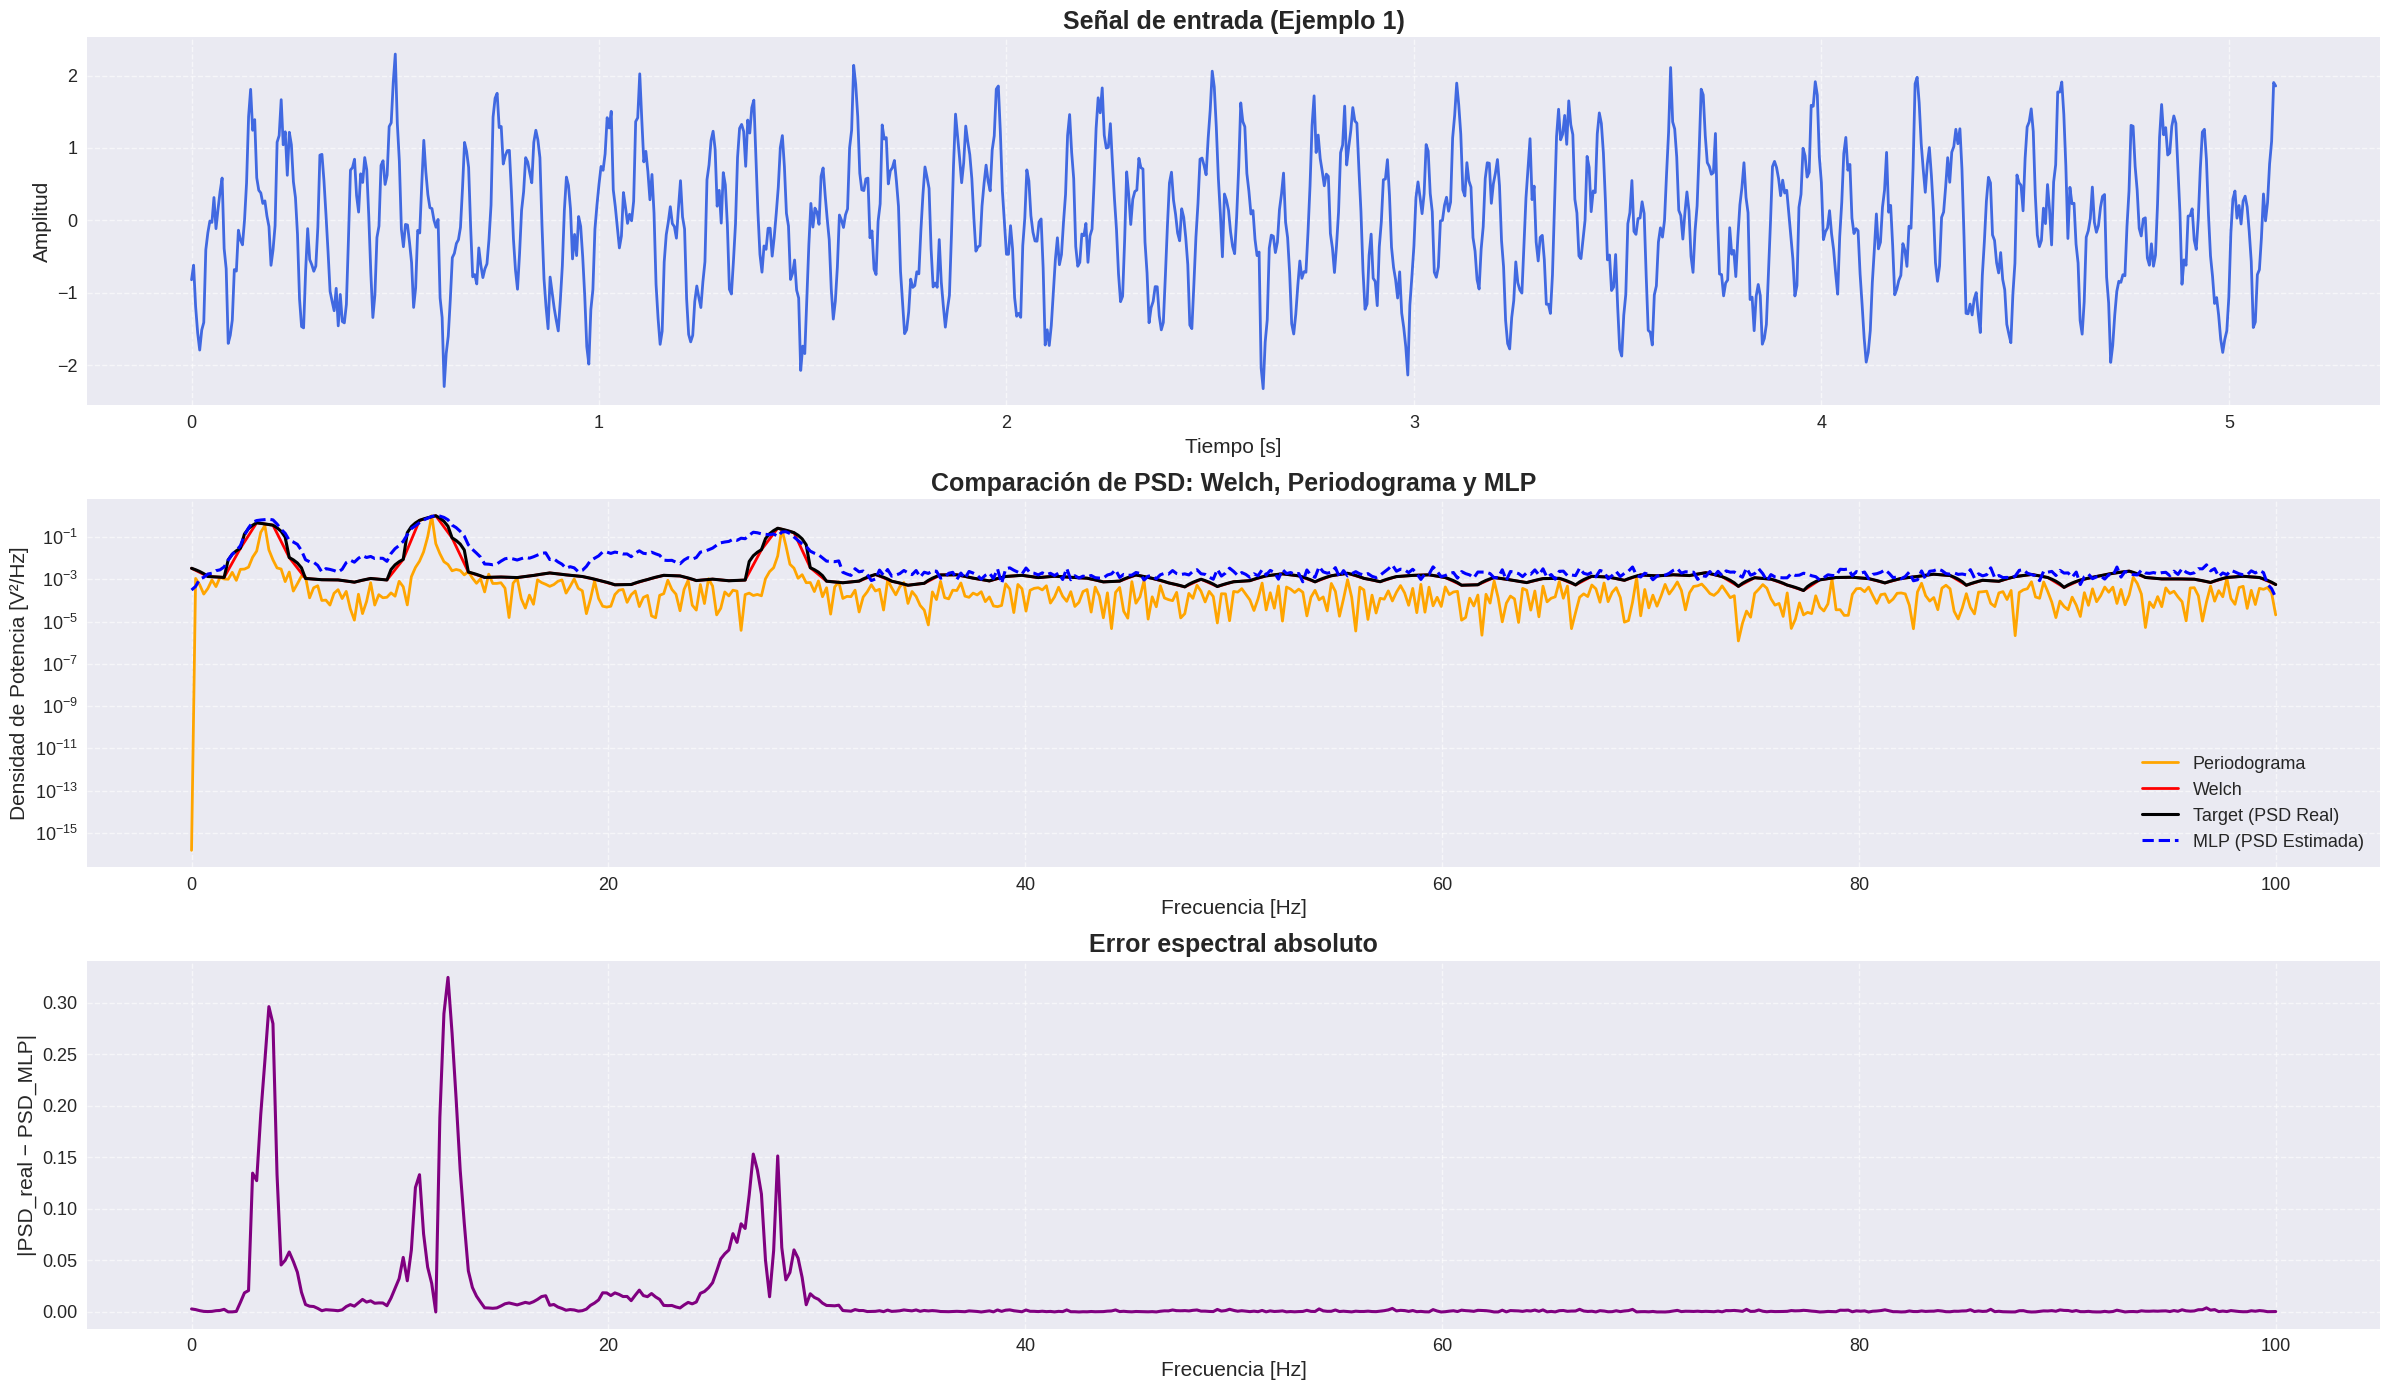

🔹 Ejemplo 2: MSE individual = 8.669563e-04


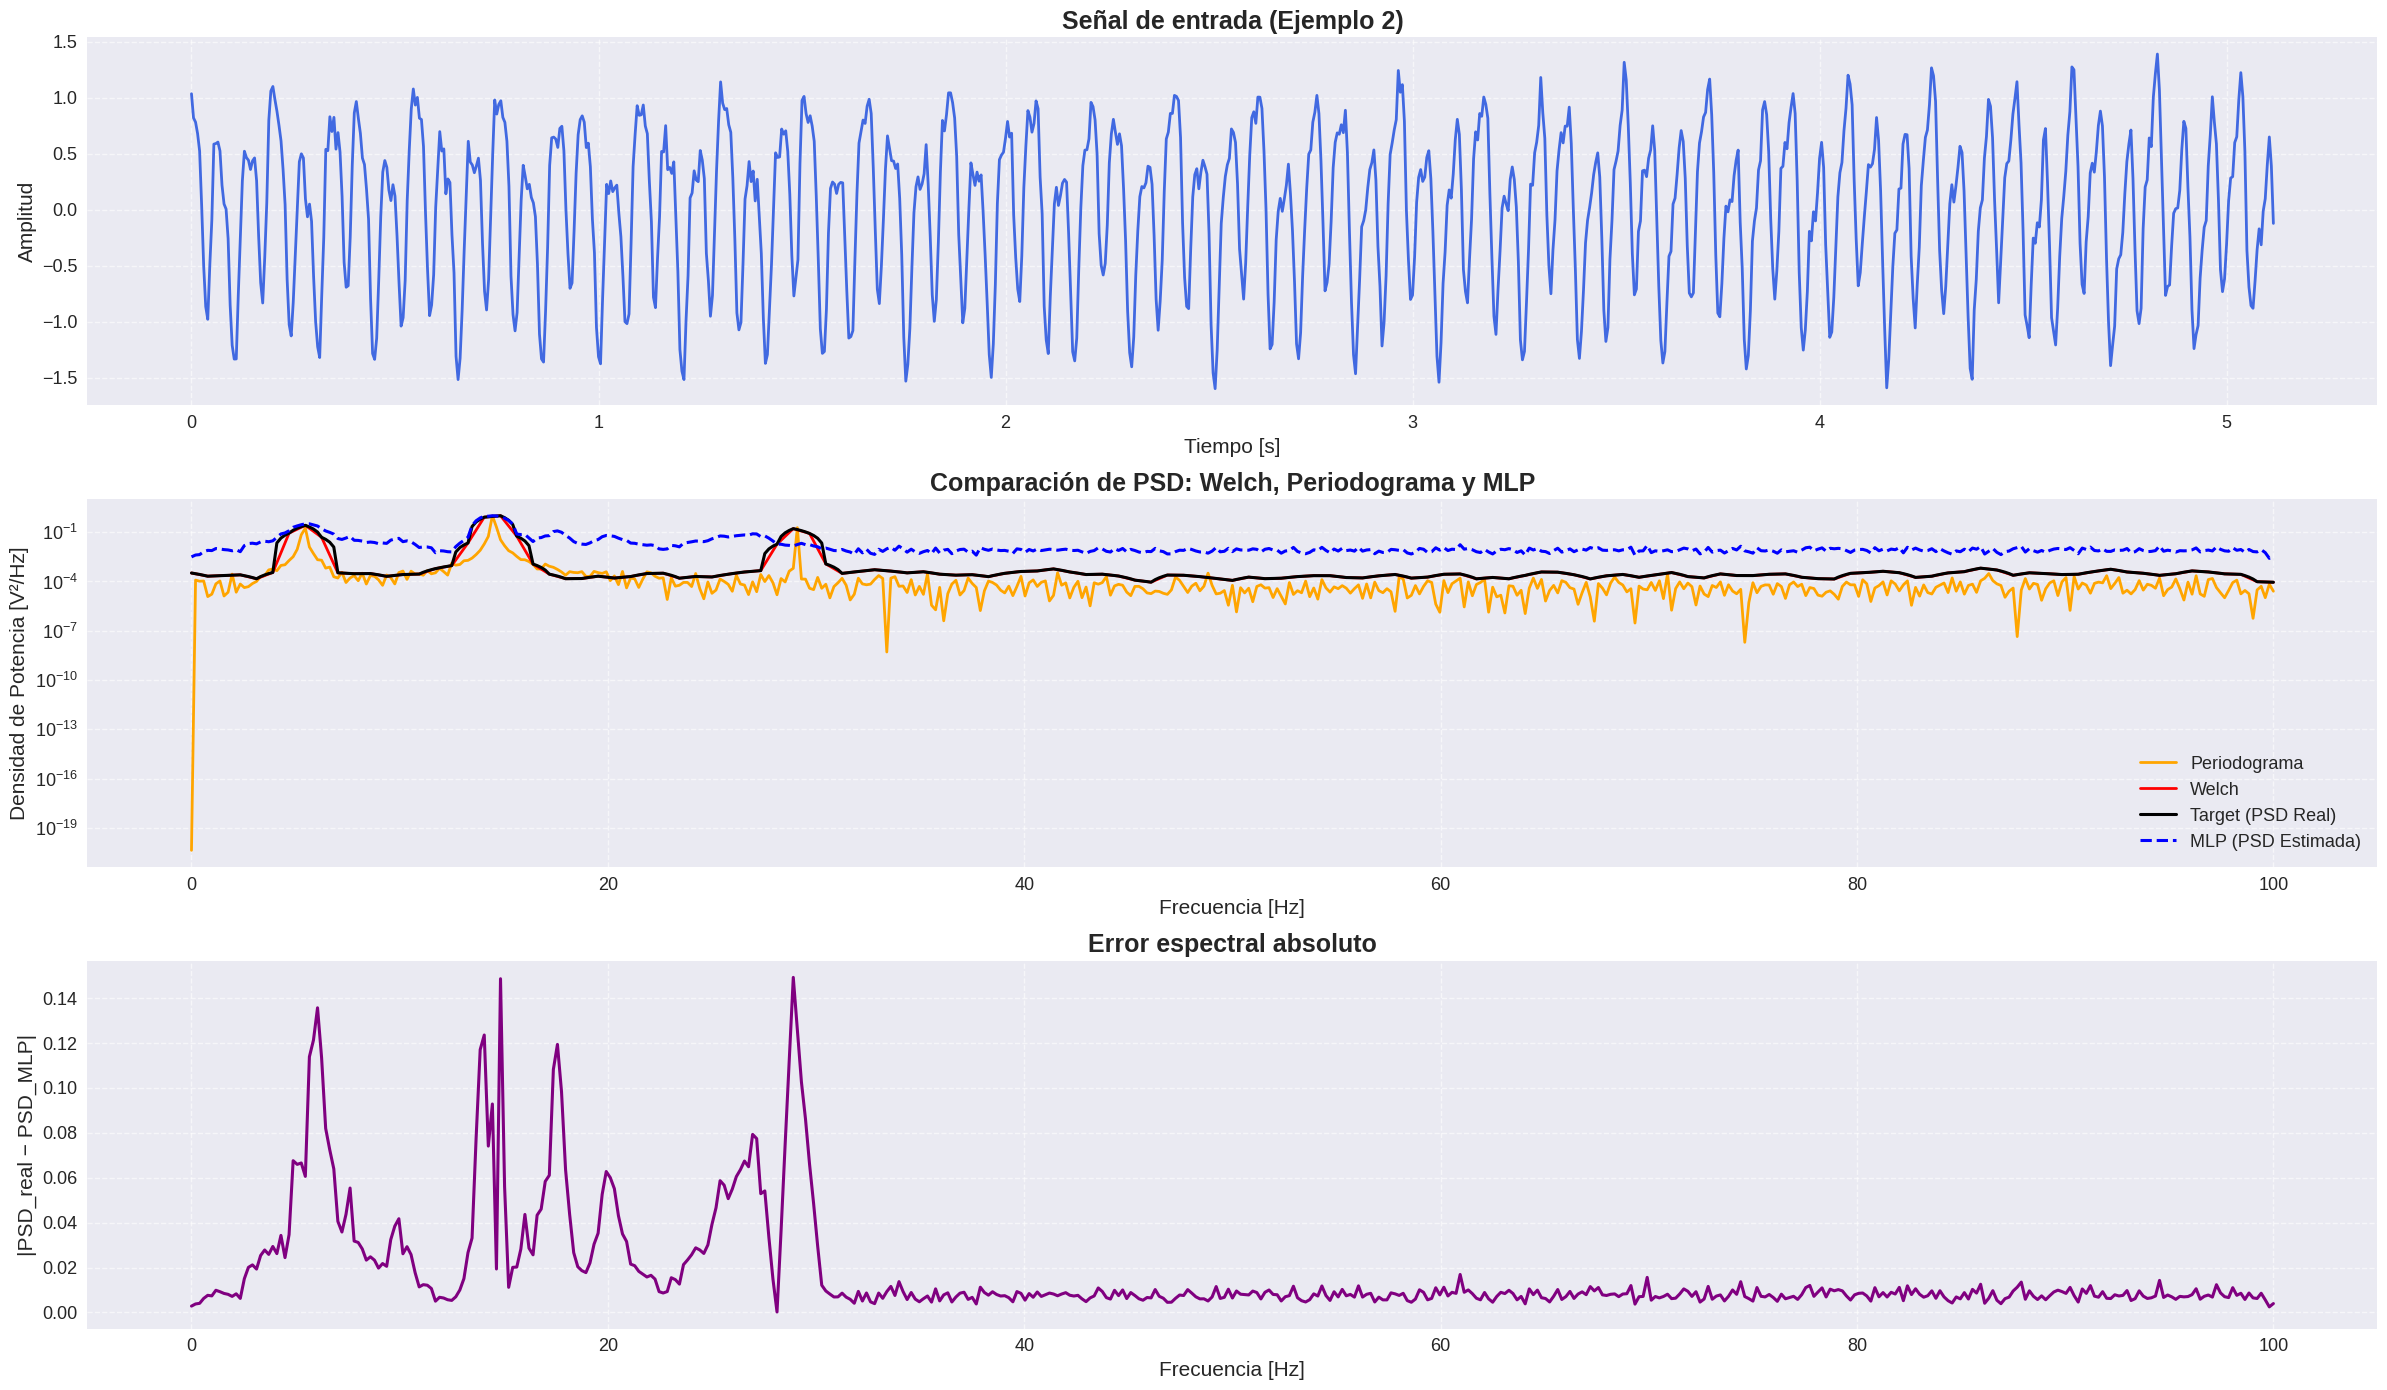

🔹 Ejemplo 3: MSE individual = 3.363317e-03


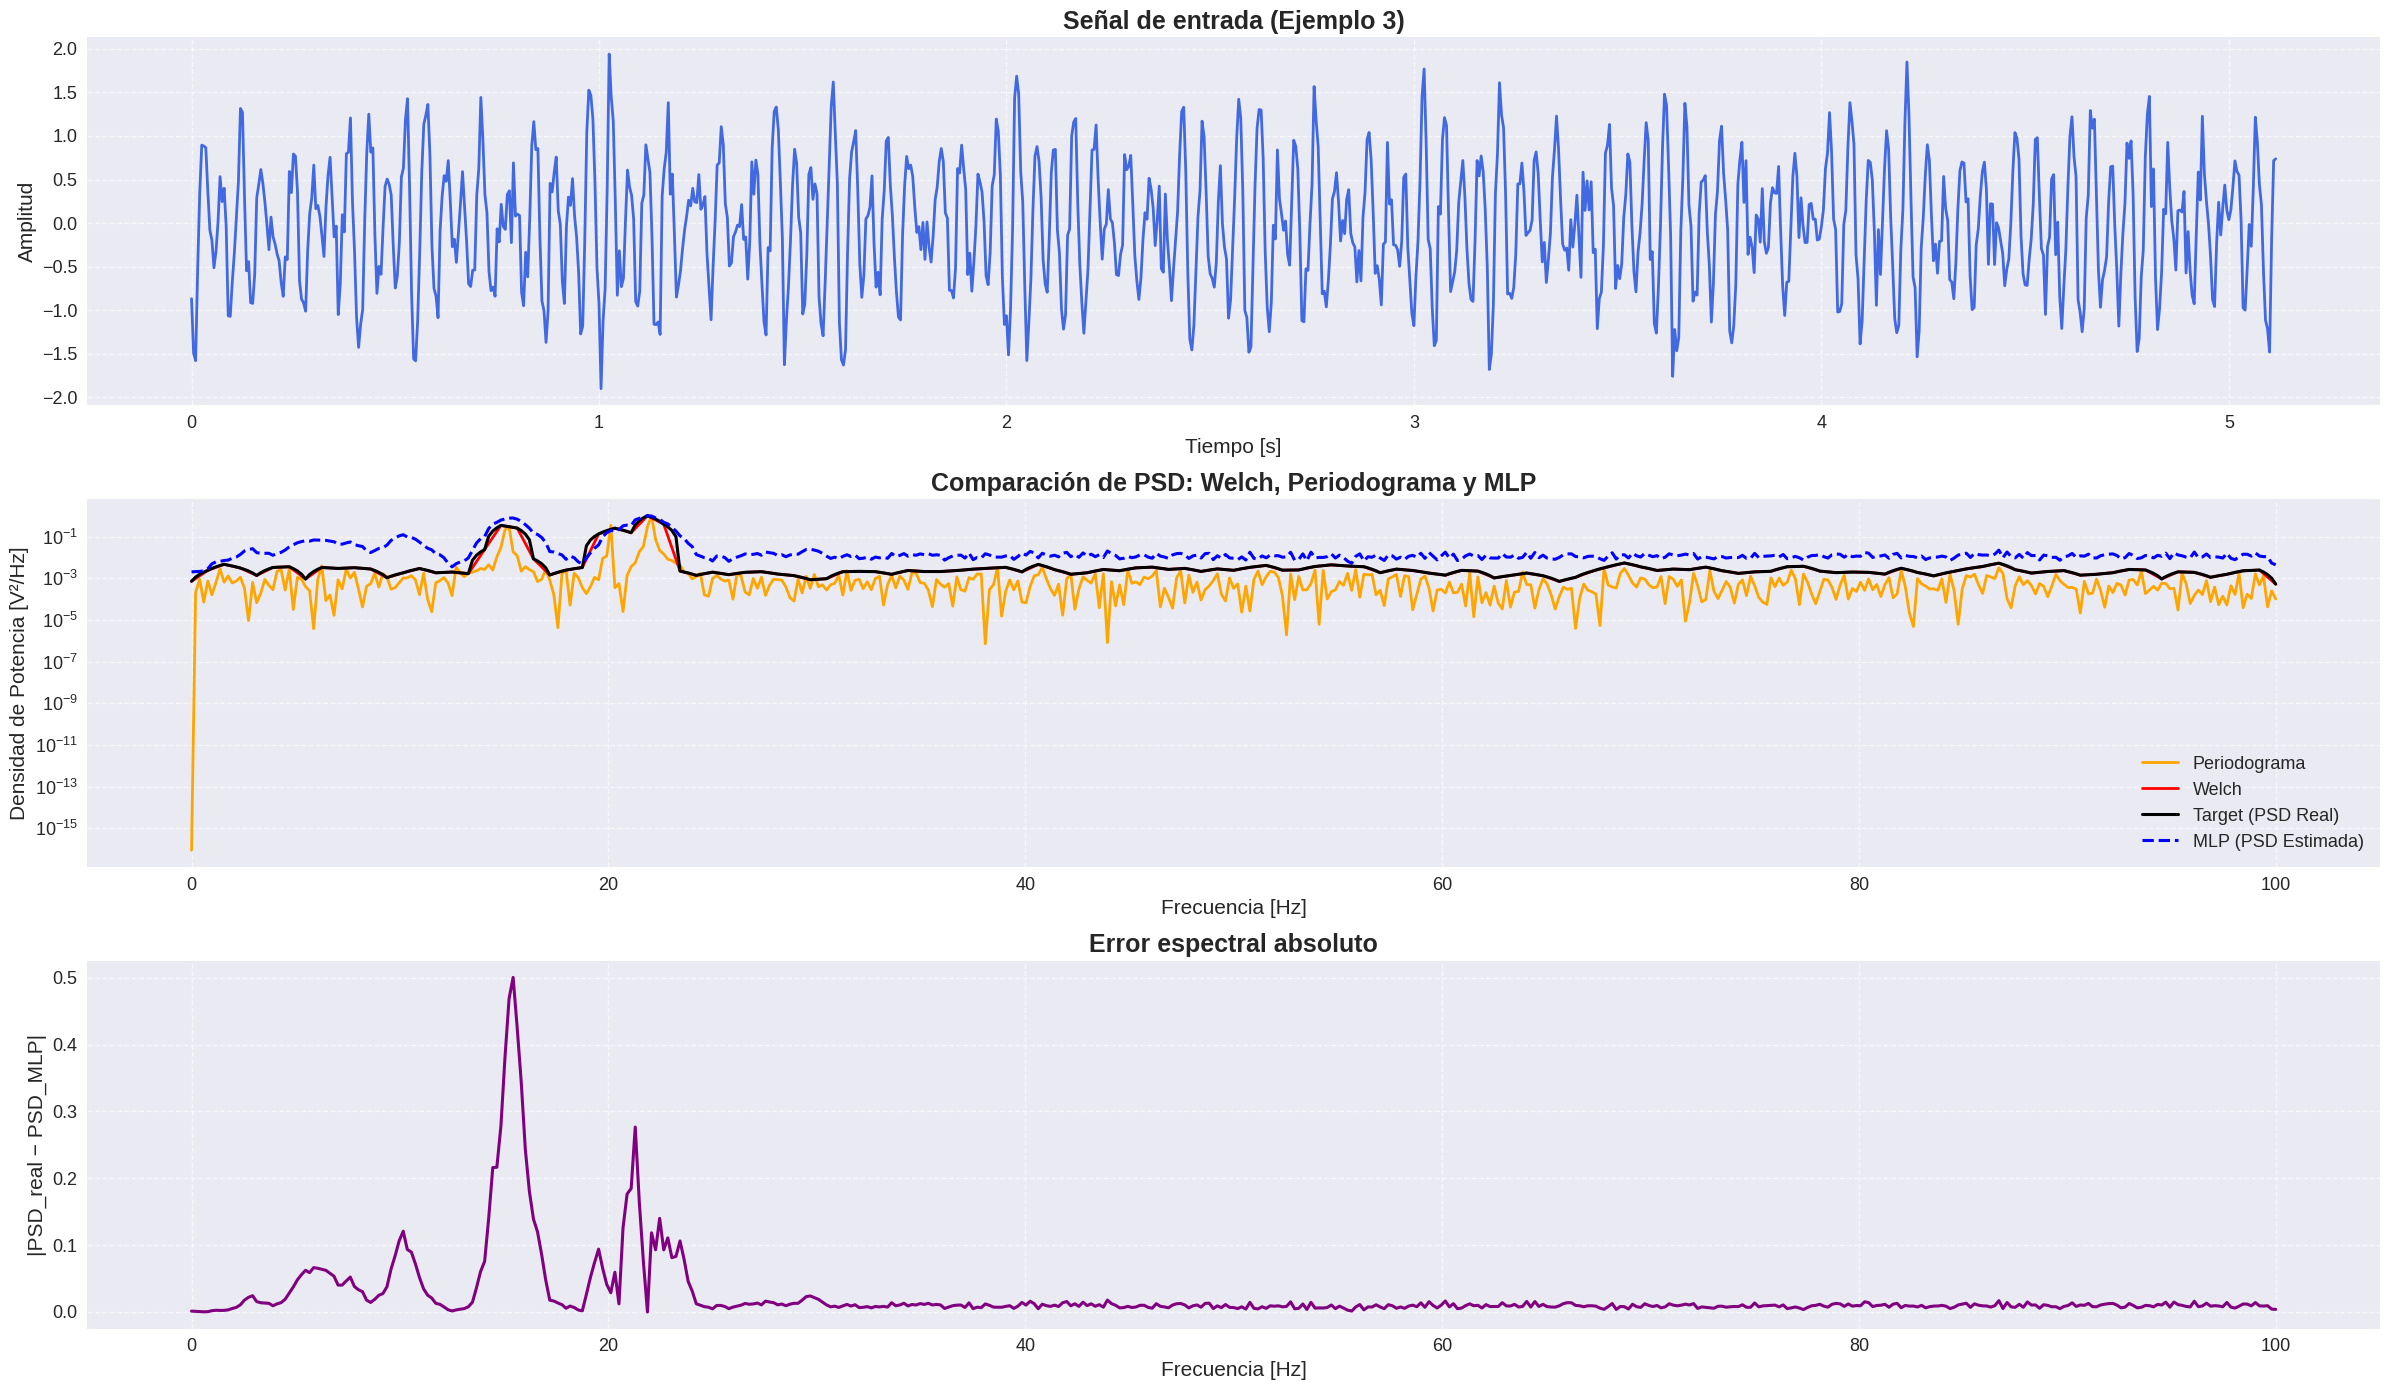

🔹 Ejemplo 4: MSE individual = 2.661864e-03


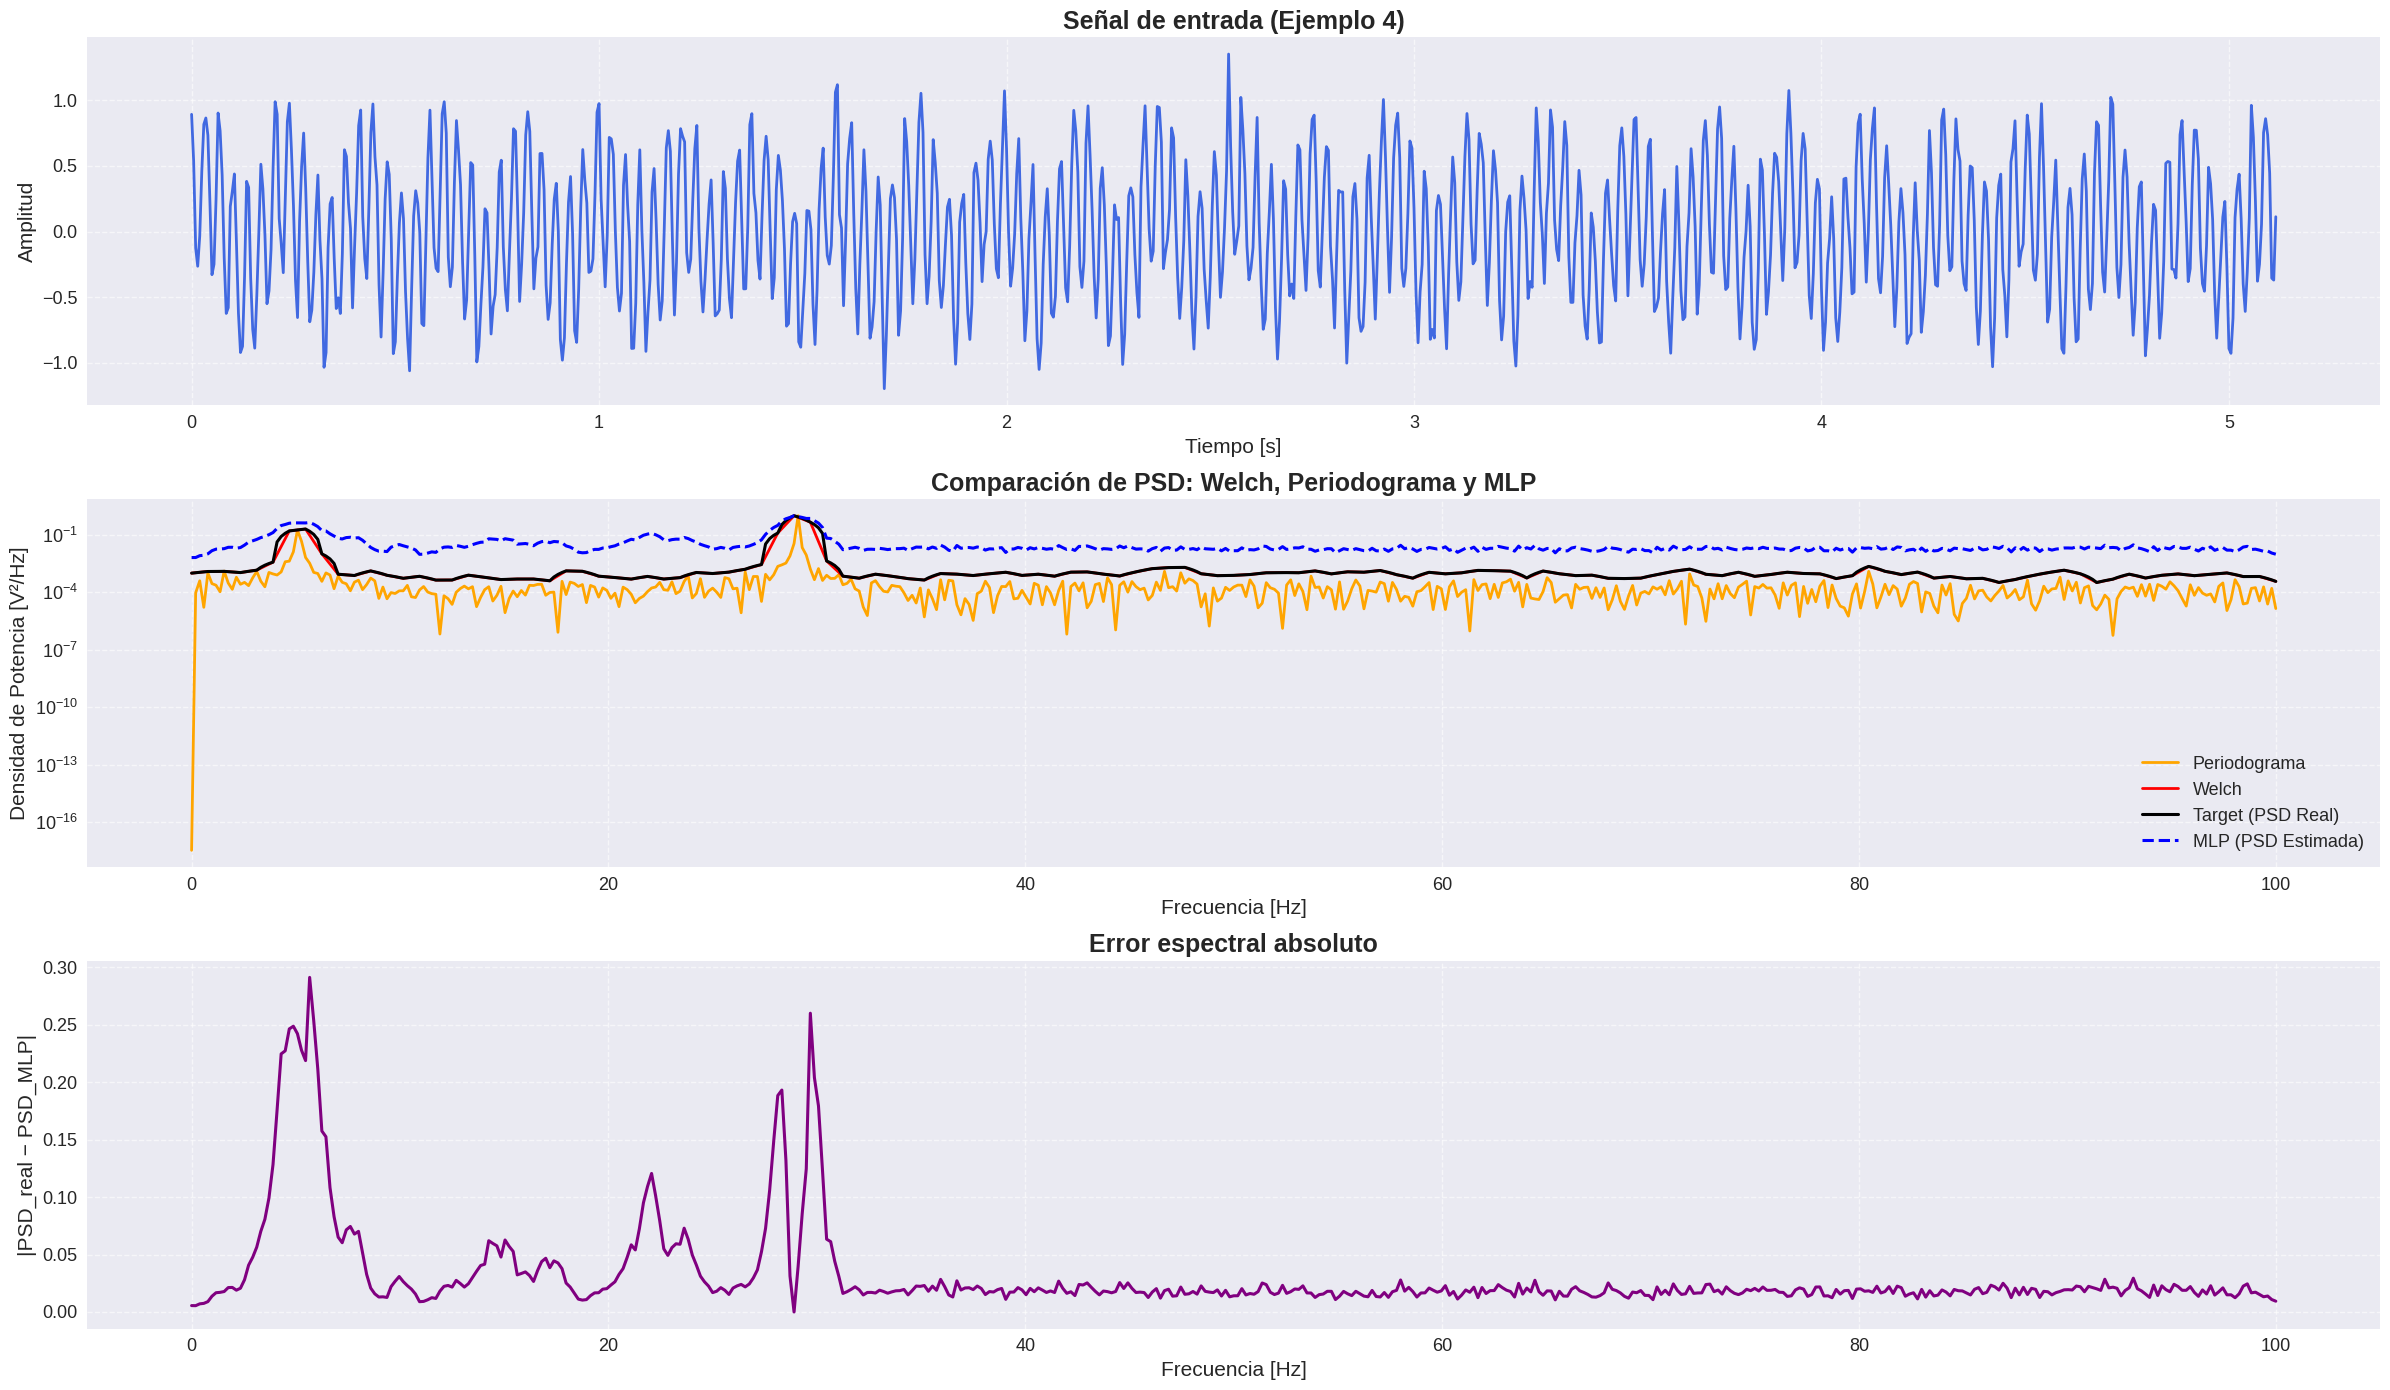

🔹 Ejemplo 5: MSE individual = 1.696035e-03


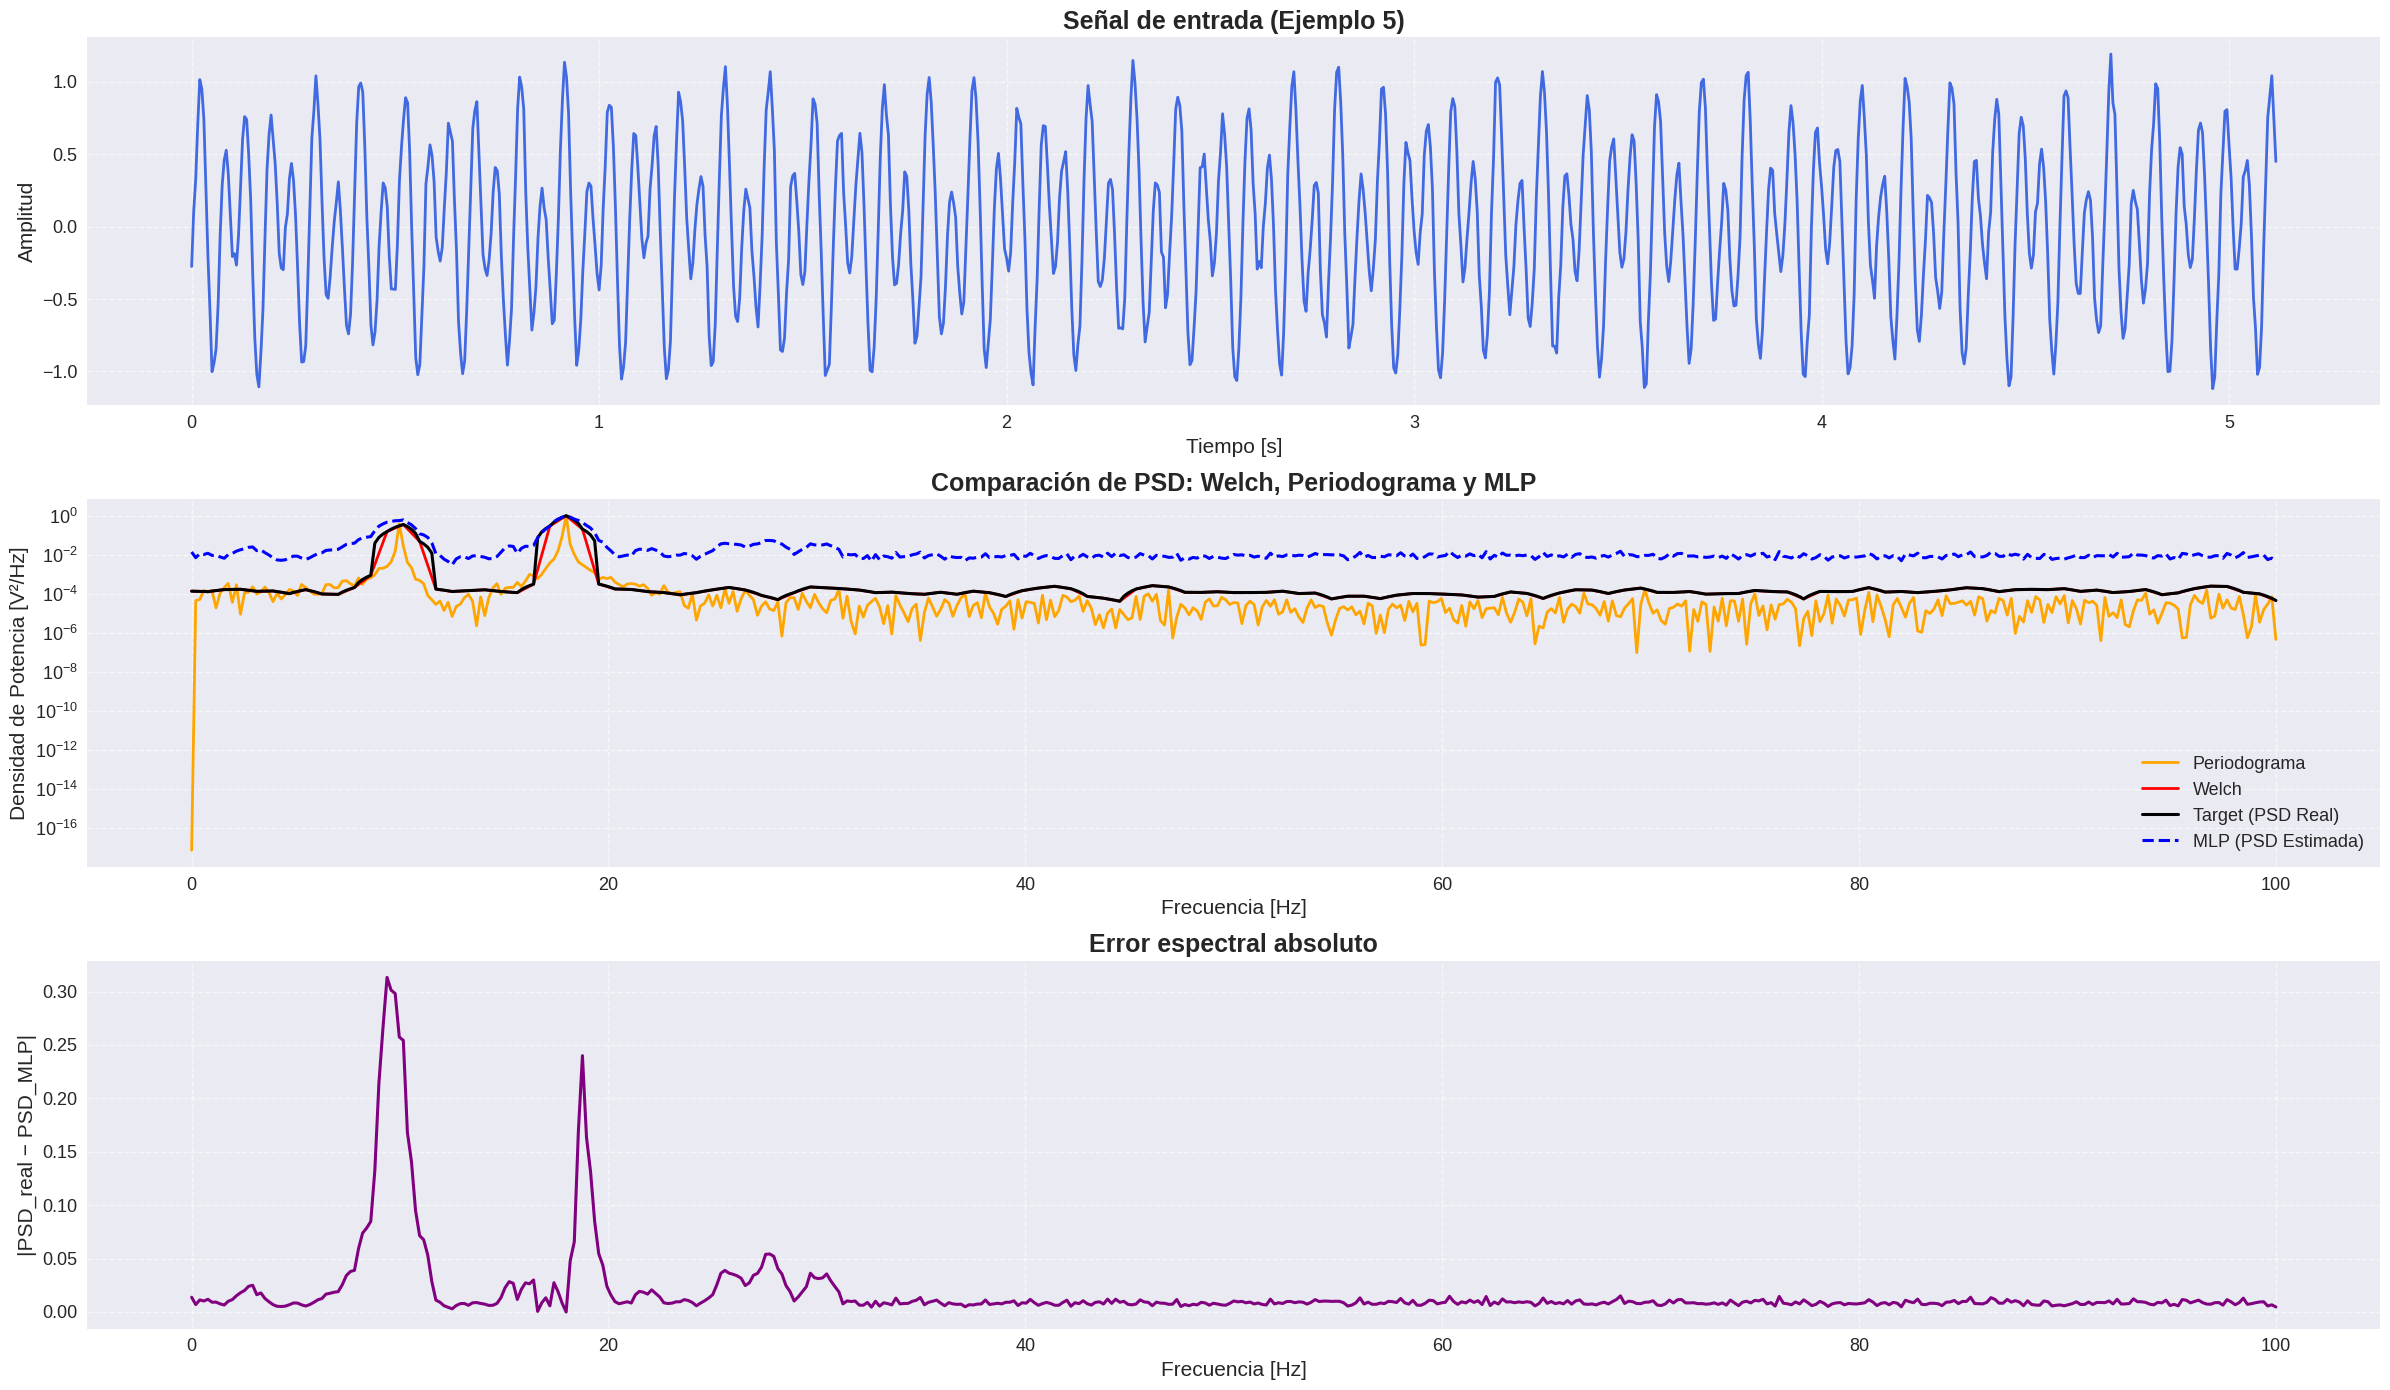


📈 Promedio del MSE en 5 ejemplos: 2.070295e-03


In [ ]:
# ===== Celda 6: Evaluación múltiple (Welch, Periodograma y error espectral) =====
from scipy.signal import welch, periodogram

N_EXAMPLES = 5  # número de señales de prueba a mostrar

model.eval()
test_loss = 0.0
preds, trues, inputs = [], [], []

# --- Inferencia sobre todo el conjunto de test ---
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        test_loss += loss.item() * xb.size(0)
        preds.append(y_pred.cpu().numpy())
        trues.append(yb.cpu().numpy())
        inputs.append(xb.cpu().numpy())

test_loss /= len(test_loader.dataset)
preds = np.vstack(preds)
trues = np.vstack(trues)
inputs = np.vstack(inputs)

print(f"\n📊 Pérdida (MSE) global en test: {test_loss:.6e}")

# -------------------------------------------------------------------
# Estimaciones múltiples
# -------------------------------------------------------------------
idx_list = np.random.choice(len(preds), N_EXAMPLES, replace=False)

for i, idx in enumerate(idx_list, start=1):
    signal_test = inputs[idx]
    f_w, Pxx_w = welch(signal_test, fs=FS, nperseg=256)
    f_p, Pxx_p = periodogram(signal_test, fs=FS)

    f_model = np.linspace(0, FS/2, SEQ_LEN//2 + 1)
    Pxx_mlp = preds[idx]
    Pxx_true = trues[idx]

    # Normalización
    Pxx_w /= np.max(Pxx_w + 1e-8)
    Pxx_p /= np.max(Pxx_p + 1e-8)
    Pxx_mlp /= np.max(Pxx_mlp + 1e-8)
    Pxx_true /= np.max(Pxx_true + 1e-8)

    # Error espectral absoluto
    error_spec = np.abs(Pxx_true - Pxx_mlp)
    mse_example = np.mean(error_spec**2)
    print(f"🔹 Ejemplo {i}: MSE individual = {mse_example:.6e}")

    # -------------------------------------------------------------------
    # Gráficas grandes por ejemplo
    # -------------------------------------------------------------------
    plt.figure(figsize=(24, 14))  # más alto para incluir tercera subgráfica

    # Señal temporal
    plt.subplot(3, 1, 1)
    plt.plot(np.arange(SEQ_LEN)/FS, signal_test, color='royalblue', linewidth=2.0)
    plt.title(f'Señal de entrada (Ejemplo {i})', fontsize=18, weight='bold')
    plt.xlabel('Tiempo [s]', fontsize=15)
    plt.ylabel('Amplitud', fontsize=15)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tick_params(axis='both', labelsize=13)

    # Comparación de PSDs
    plt.subplot(3, 1, 2)
    plt.semilogy(f_p, Pxx_p, label='Periodograma', color='orange', linewidth=2.0)
    plt.semilogy(f_w, Pxx_w, label='Welch', color='red', linewidth=2.0)
    plt.semilogy(f_model, Pxx_true, label='Target (PSD Real)', color='black', linewidth=2.2)
    plt.semilogy(f_model, Pxx_mlp, label='MLP (PSD Estimada)', linestyle='--', color='blue', linewidth=2.2)
    plt.xlabel('Frecuencia [Hz]', fontsize=15)
    plt.ylabel('Densidad de Potencia [V²/Hz]', fontsize=15)
    plt.title('Comparación de PSD: Welch, Periodograma y MLP', fontsize=18, weight='bold')
    plt.legend(fontsize=13)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tick_params(axis='both', labelsize=13)

    # Error espectral absoluto
    plt.subplot(3, 1, 3)
    plt.plot(f_model, error_spec, color='purple', linewidth=2.2)
    plt.xlabel('Frecuencia [Hz]', fontsize=15)
    plt.ylabel('|PSD_real − PSD_MLP|', fontsize=15)
    plt.title('Error espectral absoluto', fontsize=18, weight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tick_params(axis='both', labelsize=13)

    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------------
# Métrica promedio de los ejemplos
# -------------------------------------------------------------------
mse_avg = np.mean([np.mean((trues[idx] - preds[idx])**2) for idx in idx_list])
print(f"\n📈 Promedio del MSE en {N_EXAMPLES} ejemplos: {mse_avg:.6e}")
